Index(['timestamp', 'SOC', 'SOH', 'terminal_voltage', 'battery_current',
       'battery_temp', 'ambient_temp', 'internal_resistance', 'action_current',
       'action_voltage', 'dT_dt', 'dV_dt', 'soc_delta', 'thermal_stress_index',
       'aging_indicator', 'charging_efficiency', 'charging_time',
       'cycle_degradation', 'over_temp_flag', 'over_voltage_flag',
       'balancing_time'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             1900 non-null   int64  
 1   SOC                   1900 non-null   float64
 2   SOH                   1900 non-null   float64
 3   terminal_voltage      1900 non-null   float64
 4   battery_current       1900 non-null   float64
 5   battery_temp          1900 non-null   float64
 6   ambient_temp          1900 non-null   float64
 7   internal_resistance   1900 no

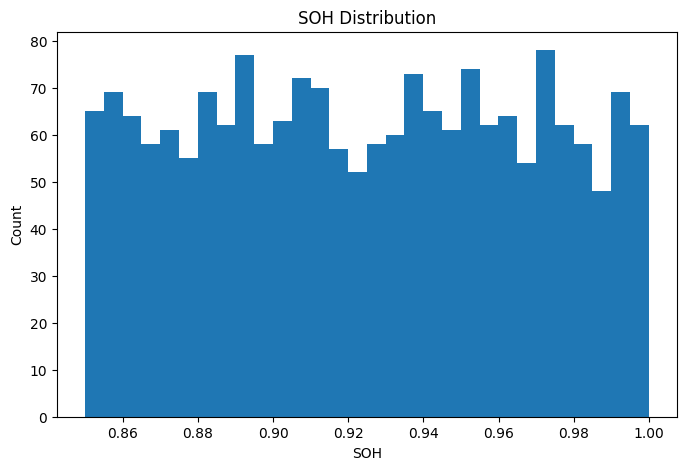

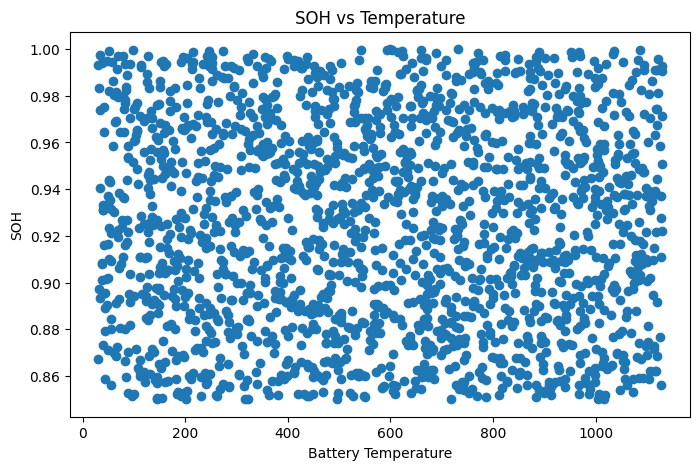

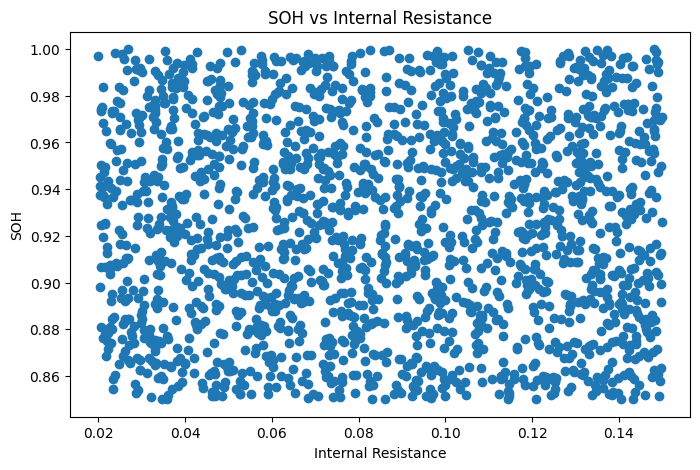

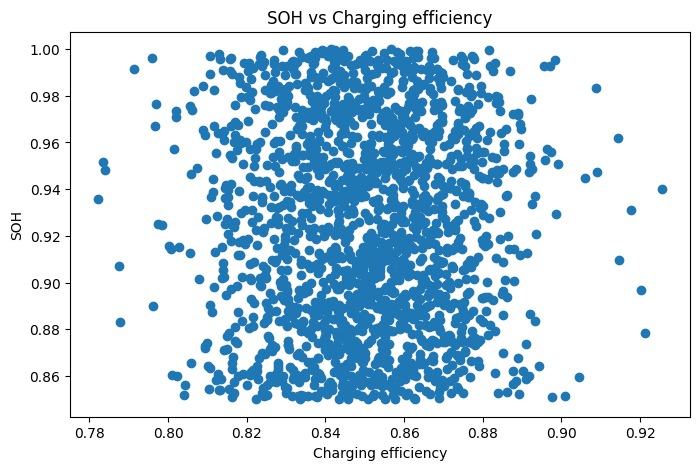

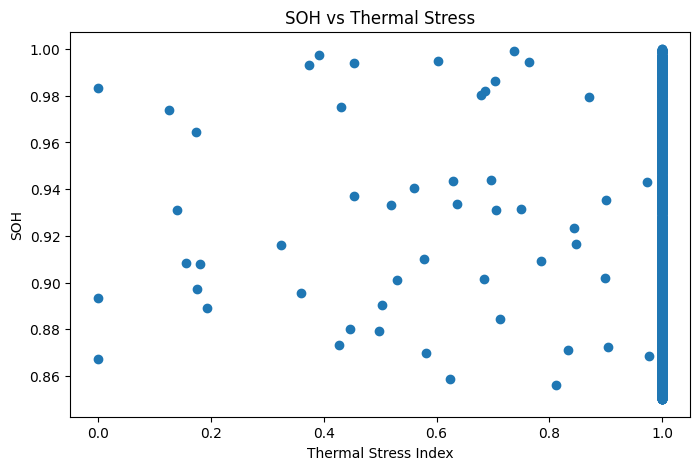

                           SOH  battery_temp  internal_resistance  \
SOH                   1.000000     -0.018036            -0.003852   
battery_temp         -0.018036      1.000000            -0.020830   
internal_resistance  -0.003852     -0.020830             1.000000   
thermal_stress_index -0.007932      0.246670            -0.003836   
aging_indicator      -0.002354     -0.011833             0.653380   
charging_efficiency   0.002200      0.024965             0.008852   
cycle_degradation     0.005725      0.000890             0.038398   

                      thermal_stress_index  aging_indicator  \
SOH                              -0.007932        -0.002354   
battery_temp                      0.246670        -0.011833   
internal_resistance              -0.003836         0.653380   
thermal_stress_index              1.000000        -0.006214   
aging_indicator                  -0.006214         1.000000   
charging_efficiency               0.006108         0.002715   
cycle_

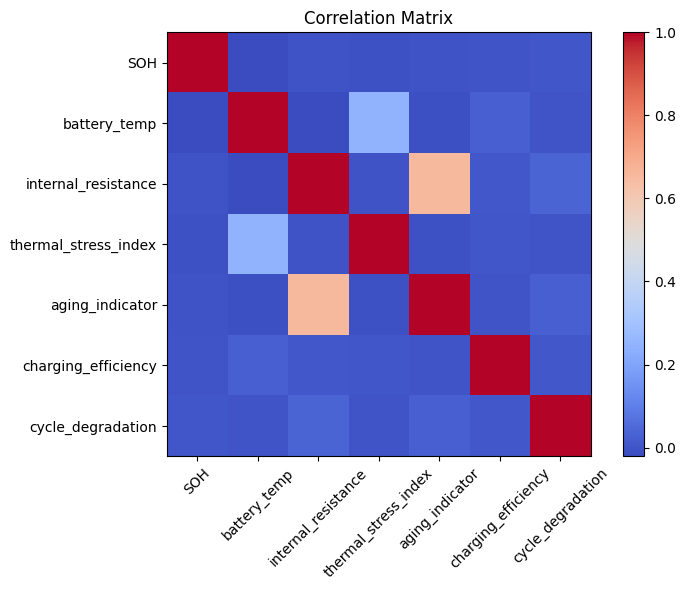

Status
Inspect    1900
Name: count, dtype: int64

Fleet Health Summary
-------------------
Average SOH: 0.92
Status
Inspect    0.924552
Name: SOH, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


battery_data = pd.read_csv("new_battery_charging.csv")
print(battery_data.columns)

print(battery_data.info())

print("\nMissing Values")
print(battery_data.isnull().sum())

print("\nDuplicate Rows")
print(battery_data.duplicated().sum())

print("\nStatistics")
print(battery_data.describe())

plt.figure(figsize=(8,5))
plt.hist(battery_data['SOH'], bins=30)
plt.title("SOH Distribution")
plt.xlabel("SOH")
plt.ylabel("Count")
plt.savefig("SOH_distribution.png")
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(
    battery_data['battery_temp'],
    battery_data['SOH']
)

plt.xlabel("Battery Temperature")
plt.ylabel("SOH")
plt.title("SOH vs Temperature")
plt.savefig("SOH_vs_Temperature.png")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(
    battery_data['internal_resistance'],
    battery_data['SOH']
)

plt.xlabel("Internal Resistance")
plt.ylabel("SOH")
plt.title("SOH vs Internal Resistance")
plt.savefig("SOH_vs_Internal Resistance.png")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(
    battery_data['charging_efficiency'],
    battery_data['SOH']
)

plt.xlabel("Charging efficiency")
plt.ylabel("SOH")
plt.title("SOH vs Charging efficiency")
plt.savefig("SOH_vs_Charging_efficiency.png")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(
    battery_data['thermal_stress_index'],
    battery_data['SOH']
)

plt.xlabel("Thermal Stress Index")
plt.ylabel("SOH")
plt.title("SOH vs Thermal Stress")
plt.savefig("SOH_vs_Thermal_Stress.png")
plt.show()



selected_columns = [
    'SOH',
    'battery_temp',
    'internal_resistance',
    'thermal_stress_index',
    'aging_indicator',
    'charging_efficiency',
    'cycle_degradation'
]

corr_matrix = battery_data[selected_columns].corr()

print(corr_matrix)

correlation_to_soh = corr_matrix['SOH']

print(
    correlation_to_soh.sort_values()
)

print("\nTop Degradation Drivers:")

print(
    correlation_to_soh
    .drop('SOH')
    .sort_values()
    .head(3)
)

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig("correlation_matrix.png")

plt.show()

def battery_status(soh):

    if soh >= 90:
        return "Healthy"
    
    elif soh >= 80:
        return "Monitor"
    
    else:
        return "Inspect"
    

battery_data['Status'] = battery_data['SOH'].apply(battery_status)

print(
    battery_data['Status'].value_counts()
)

average_SOH = battery_data['SOH'].mean()

print("\nFleet Health Summary")
print("-------------------")
print(f"Average SOH: {average_SOH:.2f}")

print(
    battery_data.groupby('Status')['SOH']
    .mean()
)











